## analyze data from dating app OKCupid

In [1]:
import numpy as np
import pandas as pd

In [2]:
from matplotlib import pyplot as plt
import seaborn as sns

In [127]:
import ipywidgets as widgets
from IPython.display import display, Markdown

In [3]:
ds = pd.read_csv('profiles.csv')

### EDA

In [2]:
ds.head()

,age,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,...,location,offspring,orientation,pets,religion,sex,sign,smokes,speaks,status
0,22,a little extra,strictly anything,socially,never,working on college/university,about me:<br />\n<br />\ni would love to think...,currently working as an international agent fo...,making people laugh.<br />\nranting about a go...,"the way i look. i am a six foot half asian, ha...",...,"south san francisco, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism and very serious about it,m,gemini,sometimes,english,single
1,35,average,mostly other,often,sometimes,working on space camp,i am a chef: this is what that means.<br />\n1...,dedicating everyday to being an unbelievable b...,being silly. having ridiculous amonts of fun w...,NaN,...,"oakland, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism but not too serious about it,m,cancer,no,"english (fluently), spanish (poorly), french (...",single
2,38,thin,anything,socially,NaN,graduated from masters program,"i'm not ashamed of much, but writing public te...","i make nerdy software for musicians, artists, ...",improvising in different contexts. alternating...,my large jaw and large glasses are the physica...,...,"san francisco, california",NaN,straight,has cats,NaN,m,pisces but it doesn&rsquo;t matter,no,"english, french, c++",available
3,23,thin,vegetarian,socially,NaN,working on college/university,i work in a library and go to school. . .,reading things written by old dead people,playing synthesizers and organizing books acco...,socially awkward but i do my best,...,"berkeley, california",doesn&rsquo;t want kids,straight,likes cats,NaN,m,pisces,no,"english, german (poorly)",single
4,29,athletic,NaN,socially,never,graduated from college/university,hey how's it going? currently vague on the pro...,work work work work + play,creating imagery to look at:<br />\nhttp://bag...,i smile a lot and my inquisitive nature,...,"san francisco, california",NaN,straight,likes dogs and likes cats,NaN,m,aquarius,no,english,single


In [3]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 31 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          59946 non-null  int64  
 1   body_type    54650 non-null  object 
 2   diet         35551 non-null  object 
 3   drinks       56961 non-null  object 
 4   drugs        45866 non-null  object 
 5   education    53318 non-null  object 
 6   essay0       54458 non-null  object 
 7   essay1       52374 non-null  object 
 8   essay2       50308 non-null  object 
 9   essay3       48470 non-null  object 
 10  essay4       49409 non-null  object 
 11  essay5       49096 non-null  object 
 12  essay6       46175 non-null  object 
 13  essay7       47495 non-null  object 
 14  essay8       40721 non-null  object 
 15  essay9       47343 non-null  object 
 16  ethnicity    54266 non-null  object 
 17  height       59943 non-null  float64
 18  income       59946 non-null  int64  
 19  job 

a set of open short-answer responses to :
- essay0 - My self-summary
- essay1 - What I’m doing with my life
- essay2 - I’m really good at…
- essay3 - The first thing people usually notice about me…
- essay4 - Favorite books, movies, show, music, and food
- essay5 - The six things I could never do without
- essay6 - I spend a lot of time thinking about…
- essay7 - On a typical Friday night I am…
- essay8 - The most private thing I am willing to admit
- essay9 - You should message me if…

<Axes: xlabel='age', ylabel='Count'>

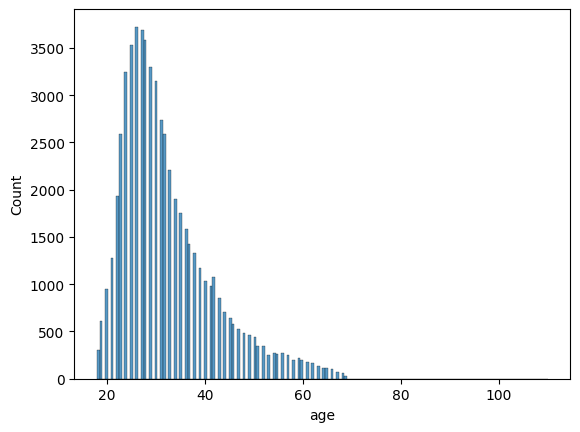

In [5]:
sns.histplot(ds.age)

In [5]:
ds.diet.value_counts()

diet
mostly anything        16585
anything                6183
strictly anything       5113
mostly vegetarian       3444
mostly other            1007
strictly vegetarian      875
vegetarian               667
strictly other           452
mostly vegan             338
other                    331
strictly vegan           228
vegan                    136
mostly kosher             86
mostly halal              48
strictly halal            18
strictly kosher           18
halal                     11
kosher                    11
Name: count, dtype: int64

In [6]:
ds.drinks.value_counts()

drinks
socially       41780
rarely          5957
often           5164
not at all      3267
very often       471
desperately      322
Name: count, dtype: int64

In [8]:
ds.smokes.value_counts()

smokes
no                43896
sometimes          3787
when drinking      3040
yes                2231
trying to quit     1480
Name: count, dtype: int64

In [24]:
ds.drugs.value_counts()

drugs
never        37724
sometimes     7732
often          410
Name: count, dtype: int64

In [9]:
ds.education.value_counts()

education
graduated from college/university    23959
graduated from masters program        8961
working on college/university         5712
working on masters program            1683
graduated from two-year college       1531
graduated from high school            1428
graduated from ph.d program           1272
graduated from law school             1122
working on two-year college           1074
dropped out of college/university      995
working on ph.d program                983
college/university                     801
graduated from space camp              657
dropped out of space camp              523
graduated from med school              446
working on space camp                  445
working on law school                  269
two-year college                       222
working on med school                  212
dropped out of two-year college        191
dropped out of masters program         140
masters program                        136
dropped out of ph.d program            127
d

In [6]:
ds.ethnicity.value_counts()

ethnicity
white                                                                               32831
asian                                                                                6134
hispanic / latin                                                                     2823
black                                                                                2008
other                                                                                1706
                                                                                    ...  
asian, black, pacific islander, hispanic / latin, white                                 1
asian, native american, indian, pacific islander, hispanic / latin, white, other        1
asian, middle eastern, black, pacific islander, hispanic / latin                        1
asian, black, pacific islander, white, other                                            1
asian, black, indian                                                                    1


In [10]:
ds.orientation.value_counts()

orientation
straight    51606
gay          5573
bisexual     2767
Name: count, dtype: int64

In [11]:
ds.sex.value_counts()

sex
m    35829
f    24117
Name: count, dtype: int64

In [13]:
ds.status.value_counts()

status
single            55697
seeing someone     2064
available          1865
married             310
unknown              10
Name: count, dtype: int64

In [16]:
ds.sign.value_counts()

sign
gemini and it&rsquo;s fun to think about         1782
scorpio and it&rsquo;s fun to think about        1772
leo and it&rsquo;s fun to think about            1692
libra and it&rsquo;s fun to think about          1649
taurus and it&rsquo;s fun to think about         1640
cancer and it&rsquo;s fun to think about         1597
pisces and it&rsquo;s fun to think about         1592
sagittarius and it&rsquo;s fun to think about    1583
virgo and it&rsquo;s fun to think about          1574
aries and it&rsquo;s fun to think about          1573
aquarius and it&rsquo;s fun to think about       1503
virgo but it doesn&rsquo;t matter                1497
leo but it doesn&rsquo;t matter                  1457
cancer but it doesn&rsquo;t matter               1454
gemini but it doesn&rsquo;t matter               1453
taurus but it doesn&rsquo;t matter               1450
aquarius but it doesn&rsquo;t matter             1408
libra but it doesn&rsquo;t matter                1408
capricorn and it&rsquo;

In [7]:
ds.location.value_counts()

location
san francisco, california    31064
oakland, california           7214
berkeley, california          4212
san mateo, california         1331
palo alto, california         1064
                             ...  
denver, colorado                 1
seattle, washington              1
cincinnati, ohio                 1
phoenix, arizona                 1
rochester, michigan              1
Name: count, Length: 199, dtype: int64

In [8]:
ds.offspring.value_counts()

offspring
doesn&rsquo;t have kids                                7560
doesn&rsquo;t have kids, but might want them           3875
doesn&rsquo;t have kids, but wants them                3565
doesn&rsquo;t want kids                                2927
has kids                                               1883
has a kid                                              1881
doesn&rsquo;t have kids, and doesn&rsquo;t want any    1132
has kids, but doesn&rsquo;t want more                   442
has a kid, but doesn&rsquo;t want more                  275
has a kid, and might want more                          231
wants kids                                              225
might want kids                                         182
has kids, and might want more                           115
has a kid, and wants more                                71
has kids, and wants more                                 21
Name: count, dtype: int64

In [9]:
ds.pets.value_counts()

pets
likes dogs and likes cats          14814
likes dogs                          7224
likes dogs and has cats             4313
has dogs                            4134
has dogs and likes cats             2333
likes dogs and dislikes cats        2029
has dogs and has cats               1474
has cats                            1406
likes cats                          1063
has dogs and dislikes cats           552
dislikes dogs and likes cats         240
dislikes dogs and dislikes cats      196
dislikes cats                        122
dislikes dogs and has cats            81
dislikes dogs                         44
Name: count, dtype: int64

In [10]:
ds.religion.value_counts()

religion
agnosticism                                   2724
other                                         2691
agnosticism but not too serious about it      2636
agnosticism and laughing about it             2496
catholicism but not too serious about it      2318
atheism                                       2175
other and laughing about it                   2119
atheism and laughing about it                 2074
christianity                                  1957
christianity but not too serious about it     1952
other but not too serious about it            1554
judaism but not too serious about it          1517
atheism but not too serious about it          1318
catholicism                                   1064
christianity and somewhat serious about it     927
atheism and somewhat serious about it          848
other and somewhat serious about it            846
catholicism and laughing about it              726
judaism and laughing about it                  681
buddhism but not too s

In [11]:
ds.speaks.value_counts()

speaks
english                                                                                21828
english (fluently)                                                                      6628
english (fluently), spanish (poorly)                                                    2059
english (fluently), spanish (okay)                                                      1917
english (fluently), spanish (fluently)                                                  1288
                                                                                       ...  
english (fluently), spanish (poorly), italian (poorly), khmer (poorly)                     1
english (fluently), ukrainian (fluently), russian (fluently)                               1
english (fluently), other (okay), german (okay), spanish (poorly), tagalog (poorly)        1
english (fluently), spanish (poorly), tagalog (okay), french (poorly)                      1
english (fluently), spanish (poorly), turkish (okay), persian (

### Filtering

In [29]:
cond1 = ((ds.sex == "m") & (ds.orientation != "gay")) | ((ds.sex == "f") & (ds.orientation != "straight"))

In [31]:
len(ds[cond1])

35428

In [32]:
cond2 = ds.status != "married"

In [33]:
len(ds[cond1 & cond2])

35203

In [39]:
cond3 = ~ds.drugs.isin(["sometimes", "often"])

In [41]:
len(ds[cond1 & cond2 & cond3])

29395

In [42]:
cond4 = ds.smokes == "no"

In [43]:
len(ds[cond1 & cond2 & cond3 & cond4])

21825

In [44]:
cond5 = ~ds.drinks.isin(["often", "very often", "desperately"])

In [45]:
len(ds[cond1 & cond2 & cond3 & cond4 & cond5])

20343

In [53]:
cond6 = ds.offspring.str.contains("doesn&rsquo;t want", na=False)

In [55]:
len(ds[cond1 & cond2 & cond3 & cond4 & cond5 & cond6])

1289

In [61]:
cond7 = ~ds.diet.str.contains("vegetarian|vegan", na=False)

In [62]:
len(ds[cond1 & cond2 & cond3 & cond4 & cond5 & cond6 & cond7])

1091

In [66]:
cond8 = ds.speaks.str.contains("chinese", na=False) 

In [67]:
len(ds[cond8])

3660

In [69]:
my_ds = ds[cond1 & cond2 & cond3 & cond4 & cond5 & cond6 & cond7 & cond8]

In [70]:
len(my_ds)

46

In [87]:
my_ds

,age,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,...,location,offspring,orientation,pets,religion,sex,sign,smokes,speaks,status
382,33,thin,anything,not at all,never,dropped out of college/university,"i am curious and inquisitive about the world, ...",i am always looking for and buying food that i...,"cooking. friends, family, and co-workers say t...",NaN,...,"oakland, california","doesn&rsquo;t have kids, and doesn&rsquo;t wan...",straight,has cats,atheism,m,NaN,no,"english, chinese (poorly)",single
568,23,fit,mostly anything,socially,never,graduated from college/university,"hello there!<br />\n<br />\ncollege educated, ...",i'm a technical recruiter at a small business ...,"making people laugh, making people feel better...","i have red hair and blue eyes, a nice face and...",...,"san francisco, california","doesn&rsquo;t have kids, and doesn&rsquo;t wan...",straight,likes dogs and likes cats,other,m,libra and it&rsquo;s fun to think about,no,"english (fluently), chinese (okay)",single
1521,35,average,strictly anything,socially,never,graduated from law school,this feels like a resume or something. not sur...,finally working a job that doesn't make me fee...,being indecisive. i like to think of myself as...,"i couldn't really say, since nobody's actually...",...,"san francisco, california",doesn&rsquo;t want kids,straight,has dogs and likes cats,agnosticism and laughing about it,m,capricorn but it doesn&rsquo;t matter,no,"english, spanish (okay), chinese (poorly), ara...",single
3198,18,average,mostly anything,not at all,never,working on high school,baby dyke. sci-fi writer. indie songwriter. ga...,"right now, i'm just trying to navigate high sc...",making up ridiculous stories and scenarios in ...,"well, i used to be short, but i'm not anymore,...",...,"green brae, california","doesn&rsquo;t have kids, and doesn&rsquo;t wan...",gay,likes dogs and has cats,judaism but not too serious about it,f,taurus but it doesn&rsquo;t matter,no,"english (fluently), chinese (poorly), hebrew (...",single
3835,27,fit,NaN,rarely,never,working on med school,ignorant. complacent. helpless. these are all ...,i am a future neurologist finishing up his las...,NaN,NaN,...,"san francisco, california",doesn&rsquo;t want kids,straight,has dogs,buddhism but not too serious about it,m,sagittarius but it doesn&rsquo;t matter,no,"english (fluently), chinese (poorly)",single
4449,29,athletic,NaN,socially,never,graduated from college/university,"outgoing, charismatic, successful entrepreneur...",worked the corporate grind for six years and s...,classically trained ivory smasher since age fi...,"my height, smile, positive energy, and sense o...",...,"oakland, california",doesn&rsquo;t want kids,straight,likes dogs and likes cats,agnosticism and laughing about it,m,scorpio but it doesn&rsquo;t matter,no,"english (fluently), chinese (okay), yiddish (p...",single
5026,27,NaN,NaN,socially,never,working on college/university,i am a sweet loving caring handsome guy like p...,"done with the marines was in the reserves, wor...","helping people, comforting and caring when tim...","my handsomeness, my kind caring self where i f...",...,"san francisco, california",doesn&rsquo;t want kids,straight,likes dogs and likes cats,buddhism but not too serious about it,m,virgo and it&rsquo;s fun to think about,no,"english (fluently), chinese (fluently)",single
13832,22,skinny,mostly anything,socially,never,graduated from two-year college,sex and gender are often used interchangably. ...,i have an obscure and fairly useless associate...,cooking. i have been making meals for my famil...,"people always notice my appearance first, espe...",...,"san francisco, california","doesn&rsquo;t have kids, and doesn&rsquo;t wan...",bisexual,dislikes dogs and likes cats,agnosticism but not too serious about it,m,gemini and it&rsquo;s fun to think about,no,"english (fluently), chinese (poorly), c++ (okay)",single
14107,39,fit,strictly other,socially,NaN,graduated from colle

In [74]:
my_age = 29

In [83]:
cond9 = (my_ds.age >= my_age - 6) & (my_ds.age <= my_age + 12)

In [84]:
len(my_ds[cond9])

33

In [89]:
my_ds[cond9].education.value_counts()

education
graduated from college/university    13
working on college/university         5
graduated from masters program        4
graduated from law school             2
dropped out of college/university     1
working on med school                 1
dropped out of masters program        1
college/university                    1
graduated from ph.d program           1
graduated from high school            1
dropped out of space camp             1
working on masters program            1
working on ph.d program               1
Name: count, dtype: int64

In [90]:
my_ds[cond9].religion.value_counts()

religion
atheism                                     4
buddhism but not too serious about it       4
other and laughing about it                 4
agnosticism                                 4
agnosticism and laughing about it           3
other                                       2
buddhism and somewhat serious about it      2
agnosticism but not too serious about it    2
atheism but not too serious about it        2
atheism and somewhat serious about it       1
other but not too serious about it          1
judaism but not too serious about it        1
Name: count, dtype: int64

In [92]:
my_ds[cond9].ethnicity.value_counts()

ethnicity
asian                                                                                                      15
white                                                                                                       9
asian, white                                                                                                3
other                                                                                                       2
asian, middle eastern, black, native american, indian, pacific islander, hispanic / latin, white, other     1
asian, white, other                                                                                         1
asian, native american, white, other                                                                        1
Name: count, dtype: int64

In [113]:
essay_cols = ["essay0", "essay1", "essay2", "essay3", "essay4", 
              "essay5", "essay6", "essay7", "essay8", "essay9"]

cond10 = my_ds[essay_cols].notna().sum(axis=1) > 3

In [124]:
my_ds = my_ds[cond9 & cond10]

In [116]:
pd.set_option('display.max_colwidth', None)

In [137]:
ds = my_ds

In [142]:
ds.sex.value_counts()

sex
m    24
f     7
Name: count, dtype: int64

a set of open short-answer responses to :
- essay0 - My self-summary
- essay1 - What I’m doing with my life
- essay2 - I’m really good at…
- essay3 - The first thing people usually notice about me…
- essay4 - Favorite books, movies, show, music, and food
- essay5 - The six things I could never do without
- essay6 - I spend a lot of time thinking about…
- essay7 - On a typical Friday night I am…
- essay8 - The most private thing I am willing to admit
- essay9 - You should message me if…

In [ ]:
row_slider = widgets.SelectionSlider(
    options=ds.index.tolist(),
    value=ds.index[0],
    description='Row Index:',
    continuous_update=False,
    layout=widgets.Layout(width='100%'),  # Makes the slider stretch across the cell
    style={'description_width': 'initial'}
)

In [ ]:
out = widgets.Output()

In [ ]:
def update_essays(change):
    with out:
        out.clear_output(wait=True)
        row_idx = change['new']
        display(Markdown(f"### Inspecting DataFrame Row: `{row_idx}`"))
        for col in essay_cols:
            text = str(ds.loc[row_idx, col])
            formatted_text = text.replace('<br />', '\n').replace('<br>', '\n')
            display(Markdown(f"**[{col}]**\n\n{formatted_text}\n\n---"))

row_slider.observe(update_essays, names='value')

In [141]:
with out:
    display(Markdown(f"### Inspecting DataFrame Row: `{ds.index[0]}`"))
    for col in essay_cols:
        text = str(ds.loc[ds.index[0], col])
        formatted_text = text.replace('<br />', '\n').replace('<br>', '\n')
        display(Markdown(f"**[{col}]**\n\n{formatted_text}\n\n---"))

container = widgets.VBox([row_slider, out], layout=widgets.Layout(width='100%'))

display(container)

### Inspecting DataFrame Row: `382`

**[essay0]**

i am curious and inquisitive about the world, so i take every

opportunity to learn from it. i am interested in world affairs,
world history, linguistics, and science.



i believe in practicing human decency on a basic level
everyday.



i love to laugh. more than that, i love make others laugh at what
they find funny.



i like surprises in the world like <a href=
"http://www.youtube.com/watch?v=rbgmeunuvie" target=
"_blank"><u>this</u></a> and amusing things like <a href=
"http://www.youtube.com/watch?v=seqdxpda0j0" target=
"_blank"><u>this</u></a>.



for women with allergies, i have two cats.

---

**[essay1]**

i am always looking for and buying food that i know nothing about,
learning about it and experimenting with it. i will eat almost
anything, not for the shock factor, but for the experience.



i have a job that i enjoy as work.



outside of work, i am active in politics and pay a lot of attention
to world events. i'm not into electoral politics. i don't vote
against my interests by supporting a lesser evil. i view fair
trade as a hoax and free trade as a cynical lie. i am interested
in the struggles for women's rights, black rights, and immigrant
rights, among other struggles against oppression.



i get around without a car (walking, public transportation), but
not for ideological reasons. it can be a hassle, but it saves
money.

---

**[essay2]**

cooking. friends, family, and co-workers say they really enjoy the
food i cook. recent favorites: chicken stew with mulokhia, ghormeh
sabzi with lamb, and chicken adobo.

---

**[essay3]**

nan

---

...

**[essay5]**

ginger is on that list. the other things are similar to or the same
as every other person's list.

---

**[essay6]**

the world (society, history), food, and comedy.

---

**[essay7]**

usually relaxing, reading, cooking, or hanging out with friends
discussing history, politics, science, etc.

---

**[essay8]**

nan

---

**[essay9]**

you are a woman who doesn't mind a partner who doesn't drink or do
drugs.



you are not allergic to cats and can at least tolerate them.

---